# Importance of accurate elevation measurements

This notebook investigates the impact of faulty elevation on line of sight measurements or even reconstructed data.

Purely numerical and hypothetical investigations.

In [ ]:
import pathlib
savepath = pathlib.Path.home()  /'Figures'
savepath.mkdir(exist_ok=True)

Using lidar_monitoring.mplstyle as matplotlib style template
Using lidar_monitoring.mplstyle as matplotlib style template


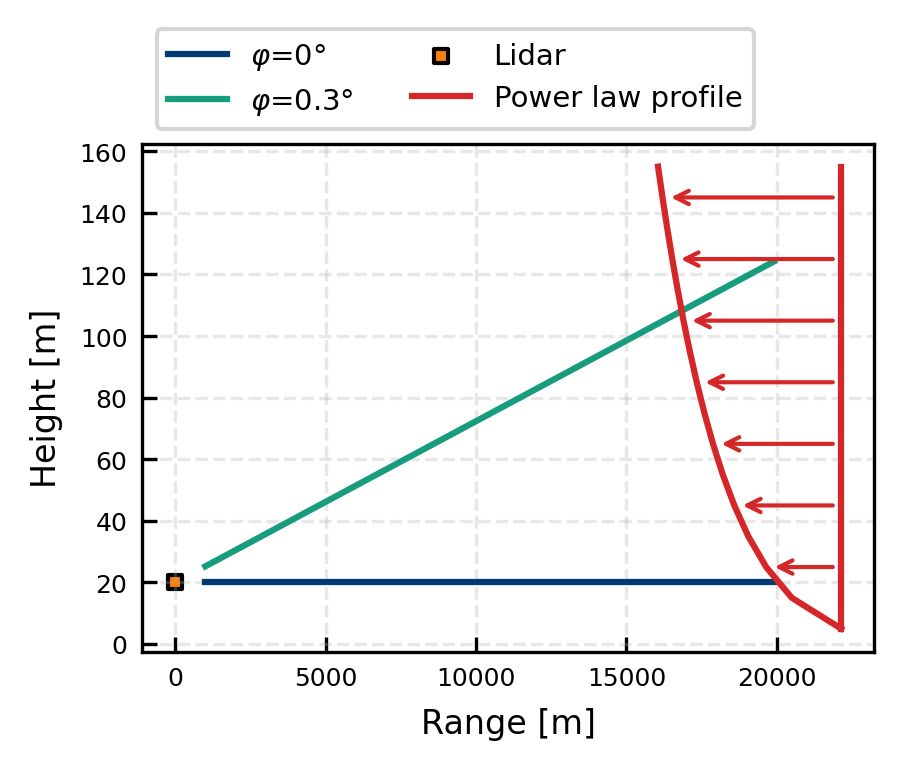

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.markers import MarkerStyle

from lidalign.utils import load_template, publication_figure
load_template()
elevation = 0
ele_offset = 0.3
h0 = 20
ranges = np.arange(1_000,20_000,100)
height = np.sin(np.deg2rad(elevation))*ranges + h0
hor = np.cos(np.deg2rad(elevation))*ranges

height2 = np.sin(np.deg2rad(elevation+ele_offset))*ranges + h0
hor2 = np.cos(np.deg2rad(elevation+ele_offset))*ranges

fig, ax = publication_figure(1/2, height = 2.2)

ax.plot(hor, height, label= fr'$\varphi$={elevation}°')
ax.plot(hor2, height2, label = fr'$\varphi$={ele_offset}°')
# Turbine(view = 'side').plot(ax = ax, xscale = 100)
ax.scatter(0,20, marker = 's',c = 'tab:orange', label = 'Lidar', s = 10, edgecolors = 'k')

ax.set(xlabel = 'Range [m]', ylabel = 'Height [m]')#, title = 'Impact of elevation on height')



c = 'tab:red'
h = np.arange(5,160,10)
x_off = 20_000+12_000
scale = 1_500
ws = x_off - 10*(h/100)**(0.14) * scale
ax.plot(ws, h, c = c, label = 'Power law profile')
ax.plot(np.zeros_like(h) + ws[0], h, c = c)



for hi, wsi in zip(h[::2], ws[::2]):
    ax.annotate('' , xytext = [ws[0], hi], xy = [wsi, hi],arrowprops=dict(arrowstyle="->", color = c))

ax.legend(loc = 'lower left', bbox_to_anchor = (0,1), ncols = 2)
plt.savefig(savepath + 'Positions_noTurbine.pdf', bbox_inches = 'tight', pad_inches = 0)



## Impact of height onto vlos retrievel


[Text(0.5, 0, 'Range [m]'),
 Text(0, 0.5, 'Power law exponent $\\alpha$ [-]'),
 Text(0.5, 1.0, 'Errors due to elevation offset of 0.3° at 10 m/s')]

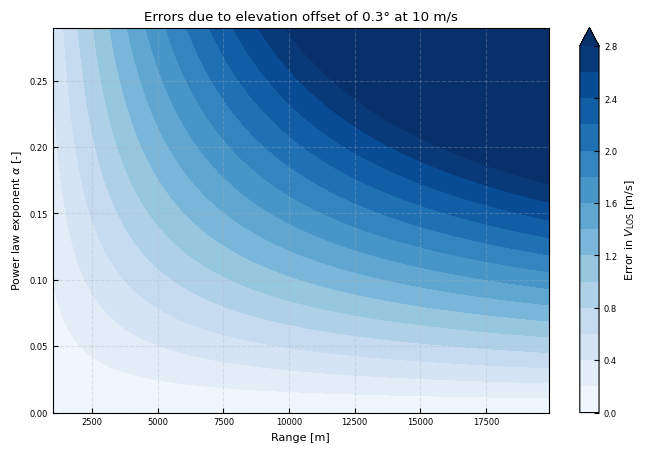

In [3]:
import numpy as np
alphas = np.arange(0,0.3,0.01)[:,np.newaxis]
ws = 10
ref_height = 100

vlos = np.cos(np.deg2rad(elevation))* ws * (height/ref_height)**alphas
vlosoff = np.cos(np.deg2rad(elevation + ele_offset))* ws * (height2/ref_height)**alphas

vlos_diff = vlosoff - vlos

fig, ax = plt.subplots()
# cb = ax.pcolormesh(ranges, alphas, vlos_diff)
cb = ax.contourf(*np.meshgrid(ranges, alphas), vlos_diff, levels = np.arange(0,3,0.2), extend = 'max', cmap = 'Blues')
plt.colorbar(cb, ax=ax, label=r'Error in $V_{\rm LOS}$' + ' [m/s]')
ax.set(xlabel = 'Range [m]', ylabel = r'Power law exponent $\alpha$ [-]', title = f'Errors due to elevation offset of {ele_offset}° at {ws} m/s')

## Or as function of elevation error

In [4]:
h = np.sin(np.deg2rad(0.5))*20_000
elevation = 0
ele_offset = 0.1
r = 20_000
alpha = 0.11
ws = 10
ref_height = 100

height = np.sin(np.deg2rad(elevation))*r + 20
height_off = np.sin(np.deg2rad(elevation + ele_offset))*r + 20

vlos = np.cos(np.deg2rad(elevation))* ws * (height/ref_height)**alpha
vlosoff = np.cos(np.deg2rad(elevation + ele_offset))* ws * (height_off/ref_height)**alpha

print(f"@{r/1000} km -- Height (no offset): {height:.1f} m, Height (with offset): {height_off:.1f} m")

print(f"Vlos no offset: {vlos:.2f}m/s, Vlos with offset: {vlosoff:.2f}m/s")

print(f"Relative difference: {(vlosoff - vlos)/vlos*100:.2f}%")


@20.0 km -- Height (no offset): 20.0 m, Height (with offset): 54.9 m
Vlos no offset: 8.38m/s, Vlos with offset: 9.36m/s
Relative difference: 11.75%


C:\Users\Paul\AppData\Local\Temp\ipykernel_37472\366093142.py:14: RuntimeWarning: invalid value encountered in power
  vlosoff = np.cos(np.deg2rad(elevation + ele_offset))* ws * (height2/ref_height)**alpha


[Text(0.5, 0, 'Range [m]'),
 Text(0, 0.5, 'Elevation error $\\Delta \\varphi$ [-]')]

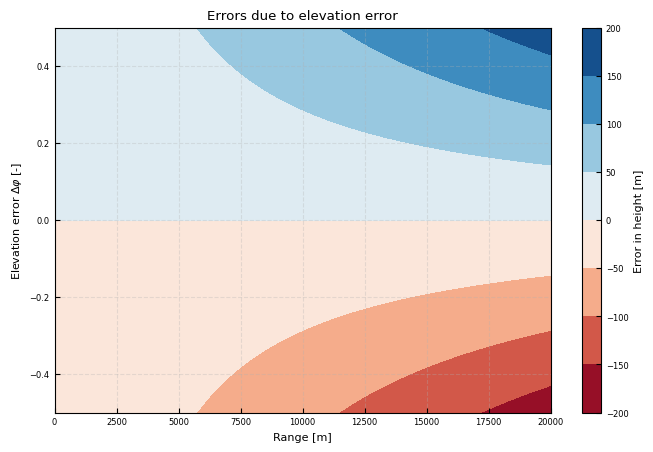

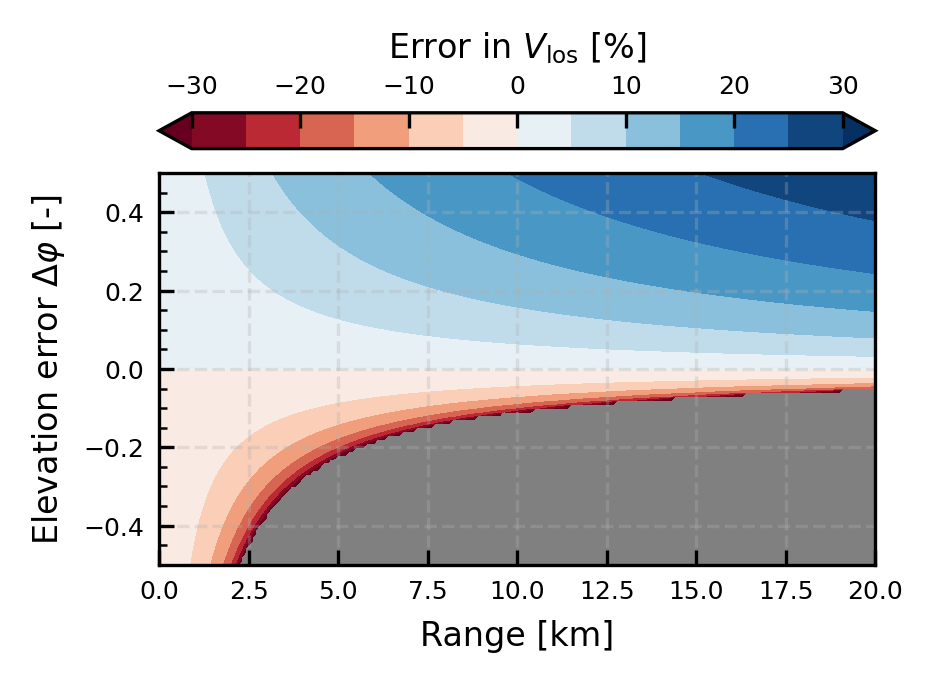

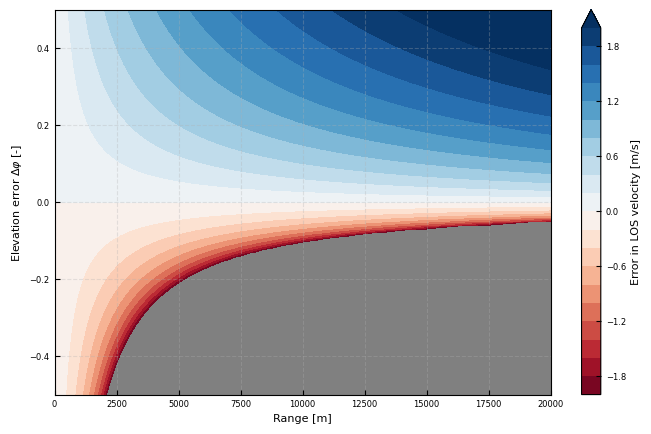

In [6]:

elevation = 0
ele_offset = np.arange(-0.5,0.501,0.01)[:,np.newaxis]  # Elevation offset in degrees
h0 = 20
ranges = np.arange(0,20_100,100)
height = np.sin(np.deg2rad(elevation))*ranges + h0

height2 = np.sin(np.deg2rad(elevation+ele_offset))*ranges + h0

alpha = 0.11
ws = 10
ref_height = 100

vlos = np.cos(np.deg2rad(elevation))* ws * (height/ref_height)**alpha
vlosoff = np.cos(np.deg2rad(elevation + ele_offset))* ws * (height2/ref_height)**alpha


vlos_diff = vlosoff - vlos
vlos_diff[height2<0]= np.nan
vlos_diff_masked = np.ma.masked_invalid(vlos_diff)

# print(vlos)

# height difference:
fig, ax = plt.subplots()
# cb = ax.pcolormesh(ranges, alphas, vlos_diff)
ax.patch.set_color('.5')
cb = ax.contourf(*np.meshgrid(ranges, ele_offset), height2-height,  cmap = 'RdBu')
# ax.contour(*np.meshgrid(ranges, ele_offset), vlos_diff_masked/ws, levels = np.arange(-0.3,0.35,0.05), cmap = 'RdBu', c = 'k')
plt.colorbar(cb, ax=ax, label='Error in height [m]')
cb.cmap.set_bad(color='lightgrey')
ax.set(xlabel = 'Range [m]', ylabel = r'Elevation error $\Delta \varphi$ [-]', title = f'Errors due to elevation error')



## relative error
# fig, ax = plt.subplots()
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = publication_figure(1/2, height = 2.3)
# cb = ax.pcolormesh(ranges, alphas, vlos_diff)
ax.patch.set_color('.5')
cb = ax.contourf(*np.meshgrid(ranges/1000, ele_offset), vlos_diff_masked/vlos*100, levels = np.arange(-0.3,0.35,0.05)*100, cmap = 'RdBu', extend = 'both')
# ax.contour(*np.meshgrid(ranges, ele_offset), vlos_diff_masked/ws, levels = np.arange(-0.3,0.35,0.05), cmap = 'RdBu', c = 'k')

# Use make_axes_locatable to create a new axis on top
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("top", size="5%", pad=0.5)

# # Create the colorbar
# plt.colorbar(cb, cax=cax, orientation='horizontal')
# cax.xaxis.set_ticks_position('top')
# cax.xaxis.set_label_position('top')

plt.colorbar(cb, ax=ax, label=r'Error in $V_{\rm los}$ [%]', location = 'top', extend = 'both')
cb.cmap.set_bad(color='lightgrey')
ax.set(xlabel = 'Range [km]', ylabel = r'Elevation error $\Delta \varphi$ [-]')#, title = f'Errors due to elevation error at {ws} m/s and' +rf' $\alpha$={alpha}')
# Enable minor ticks on y-axis
from matplotlib.ticker import AutoMinorLocator
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.tight_layout()
plt.savefig(savepath +'Relative_error.pdf', bbox_inches = 'tight', pad_inches = 0)


fig, ax = plt.subplots()
# cb = ax.pcolormesh(ranges, alphas, vlos_diff)
ax.patch.set_color('.5')
cb = ax.contourf(*np.meshgrid(ranges, ele_offset), vlos_diff_masked, levels = np.arange(-2,2.2,0.2), extend = 'max', cmap = 'RdBu')
plt.colorbar(cb, ax=ax, label='Error in LOS velocity [m/s]', extend = 'both')
cb.cmap.set_bad(color='lightgrey')
ax.set(xlabel = 'Range [m]', ylabel = r'Elevation error $\Delta \varphi$ [-]')

